In [1]:
"""Transformer Encoder モデル — USD/JPY 1分足 方向予測"""
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import optuna
import pickle
import warnings
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight

from scripts.data_loader import load_data
from scripts.features import (
    prepare_ohlcv, generate_features, get_feature_columns,
    create_target, TIME_FEATURES,
)
from scripts.evaluation import (
    predict_with_thresholds, score_trading, build_live_filter,
    run_backtest, compute_metrics, plot_equity_curve, DEFAULT_CONFIG,
)

ARTIFACT_DIR = Path("../artifacts/transformer")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

CONFIG = {
    **DEFAULT_CONFIG,
    "THRESHOLD_PIPS_MIN": 2,
    "THRESHOLD_PIPS_MAX": 10,
    "THRESHOLD_PIPS_DEFAULT": 5,
    "RANDOM_SEED": 42,
    "N_TRIALS": 10,
    "TRAIN_RATIO": 0.6,
    "VAL_RATIO": 0.2,
    "PROB_THRESHOLD_MIN": 0.40,
    "PROB_THRESHOLD_MAX": 0.80,
    "OPTUNA_TIMEOUT": 2400,
    "OPTUNA_SUBSAMPLE": 0.3,
}

np.random.seed(CONFIG["RANDOM_SEED"])
torch.manual_seed(CONFIG["RANDOM_SEED"])
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

C:\Users\daiya\OneDrive\ドキュメント\FX-speculate\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
df = load_data(str(Path.cwd().parent / "data"))
df, price_cols = prepare_ohlcv(df)
df_features = generate_features(df, price_cols)

# Transformer用: 全特徴量（raw OHLC + テクニカル指標）を使用。
# CatBoost/LightGBMではTop40選択するが、Transformerでは特徴量選択をスキップ。
# 理由: Transformerは時系列ウィンドウ入力で、Self-Attentionにより自動的に
# 重要な特徴量に注目できるため。また、ウィンドウ単位のStandardScalerにより
# 生価格の非定常性も正規化される。
feature_cols = get_feature_columns(df_features)
# OHLCも追加（Transformerは生価格パターンも学習に使う）
for col in ["open", "high", "low", "close"]:
    if col not in feature_cols:
        feature_cols.append(col)

future_returns_pips = (df_features["close"].shift(-CONFIG["PREDICT_HORIZON"]) - df_features["close"]) / CONFIG["PIP_SIZE"]

# NaN除去
X_all = df_features[feature_cols].copy()
valid_indices = X_all.dropna().index
valid_indices = valid_indices[:-CONFIG["PREDICT_HORIZON"]]
X_all = X_all.loc[valid_indices]
future_returns_pips_valid = future_returns_pips.loc[valid_indices]

print(f"Features: {len(feature_cols)}, Samples: {len(X_all)}")

Features: 99, Samples: 881522


In [3]:
def purged_split_for_transformer(X, gap_base, max_window_size):
    """Transformer用のPurged分割。gap = gap_base + max_window_size。"""
    n = len(X)
    train_end = int(n * CONFIG["TRAIN_RATIO"])
    val_end = int(n * (CONFIG["TRAIN_RATIO"] + CONFIG["VAL_RATIO"]))
    gap = gap_base + max_window_size

    train = X.iloc[:train_end]
    val_start = min(train_end + gap, n)
    val = X.iloc[val_start:val_end]
    test_start = min(val_end + gap, n)
    test = X.iloc[test_start:]

    return train, val, test

MAX_WINDOW = 120
X_train_raw, X_val_raw, X_test_raw = purged_split_for_transformer(
    X_all, CONFIG["PREDICT_HORIZON"], MAX_WINDOW
)
fr_train = future_returns_pips_valid.loc[X_train_raw.index]
fr_val = future_returns_pips_valid.loc[X_val_raw.index]
fr_test = future_returns_pips_valid.loc[X_test_raw.index]

print(f"Train: {len(X_train_raw)}, Val: {len(X_val_raw)}, Test: {len(X_test_raw)}")

Train: 528913, Val: 176169, Test: 176170


In [4]:
class TimeSeriesDataset(Dataset):
    """ウィンドウ化された時系列データセット。ウィンドウ単位で標準化。"""

    def __init__(self, X: pd.DataFrame, y: pd.Series, window_size: int):
        self.X = X.values.astype(np.float32)
        self.y = y.values.astype(np.int64)
        self.window_size = window_size
        self.valid_indices = list(range(window_size, len(X)))

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        end = self.valid_indices[idx]
        start = end - self.window_size
        window = self.X[start:end].copy()

        mean = window.mean(axis=0, keepdims=True)
        std = window.std(axis=0, keepdims=True) + 1e-8
        window = (window - mean) / std

        return torch.tensor(window), torch.tensor(self.y[end])


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class FXTransformer(nn.Module):
    def __init__(self, n_features, d_model, nhead, num_layers, dim_feedforward, dropout, num_classes=3):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(d_model, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        x = x[:, -1, :]
        x = self.dropout(x)
        return self.classifier(x)

In [5]:
def train_transformer(
    X_train, y_train, X_val, y_val,
    window_size, d_model, nhead, num_layers, dim_feedforward,
    dropout, lr, batch_size, max_epochs, patience=10,
):
    """Transformerモデルの学習。早期停止あり。"""
    train_ds = TimeSeriesDataset(X_train, y_train, window_size)
    val_ds = TimeSeriesDataset(X_val, y_val, window_size)
    pin = DEVICE.type == "cuda"
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=pin, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=batch_size, pin_memory=pin, num_workers=0)

    n_features = X_train.shape[1]
    model = FXTransformer(n_features, d_model, nhead, num_layers, dim_feedforward, dropout).to(DEVICE)

    classes = np.unique(y_train)
    weights = compute_class_weight("balanced", classes=classes, y=y_train)
    class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(max_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE, non_blocking=True), y_batch.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        scheduler.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE, non_blocking=True), y_batch.to(DEVICE, non_blocking=True)
                output = model(X_batch)
                val_loss += criterion(output, y_batch).item()
        val_loss /= len(val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    return model


def predict_transformer(model, X, y_dummy, window_size, batch_size=512):
    """Transformerモデルで予測確率を取得。"""
    ds = TimeSeriesDataset(X, y_dummy, window_size)
    loader = DataLoader(ds, batch_size=batch_size)
    model.eval()
    all_probs = []
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(DEVICE)
            output = model(X_batch)
            probs = torch.softmax(output, dim=1).cpu().numpy()
            all_probs.append(probs)
    return np.concatenate(all_probs, axis=0)

In [6]:
def objective(trial):
    threshold_pips = trial.suggest_float("threshold_pips", CONFIG["THRESHOLD_PIPS_MIN"], CONFIG["THRESHOLD_PIPS_MAX"])
    prob_threshold = trial.suggest_float("prob_threshold", CONFIG["PROB_THRESHOLD_MIN"], CONFIG["PROB_THRESHOLD_MAX"])
    window_size = trial.suggest_int("window_size", 30, 120, step=10)

    y_train = create_target(df_features.loc[X_train_raw.index], threshold_pips, CONFIG["PREDICT_HORIZON"])
    y_val = create_target(df_features.loc[X_val_raw.index], threshold_pips, CONFIG["PREDICT_HORIZON"])

    if len(np.unique(y_train)) < 3:
        return -1.0

    d_model = trial.suggest_categorical("d_model", [32, 64])
    nhead = trial.suggest_categorical("nhead", [2, 4])
    if d_model % nhead != 0:
        return -1.0

    num_layers = trial.suggest_int("num_layers", 1, 2)
    dim_feedforward = trial.suggest_categorical("dim_feedforward", [64, 128])
    dropout = trial.suggest_float("dropout", 0.1, 0.4)
    lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [256, 512])

    # Optunaトライアルでは訓練データをサブサンプリングして高速化
    subsample_ratio = CONFIG["OPTUNA_SUBSAMPLE"]
    n_sub = int(len(X_train_raw) * subsample_ratio)
    X_train_sub = X_train_raw.iloc[:n_sub]
    y_train_sub = y_train.loc[X_train_sub.index]

    try:
        model = train_transformer(
            X_train_sub, y_train_sub,
            X_val_raw, y_val.loc[X_val_raw.index],
            window_size, d_model, nhead, num_layers, dim_feedforward,
            dropout, lr, batch_size, max_epochs=20, patience=5,
        )

        probs = predict_transformer(model, X_val_raw, y_val.loc[X_val_raw.index], window_size)
        val_indices = X_val_raw.index[window_size:]
        preds = predict_with_thresholds(probs, prob_threshold, prob_threshold)

        cost_pips = CONFIG["SPREAD_PIPS"] + CONFIG["SLIPPAGE_PIPS"]
        fr_val_aligned = fr_val.loc[val_indices].values
        score = score_trading(preds, fr_val_aligned, len(preds), CONFIG, cost_pips)
        return score
    except Exception as e:
        print(f"Trial failed: {e}")
        return -1.0

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=CONFIG["N_TRIALS"], timeout=CONFIG["OPTUNA_TIMEOUT"], show_progress_bar=True)

print(f"Best score: {study.best_value:.4f}")
print(f"Completed trials: {len(study.trials)}")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/10 [00:00<?, ?it/s]

Best trial: 0. Best value: 1.8059:   0%|          | 0/10 [03:04<?, ?it/s]

Best trial: 0. Best value: 1.8059:  10%|█         | 1/10 [03:04<27:43, 184.85s/it]

Best trial: 0. Best value: 1.8059:  10%|█         | 1/10 [03:04<27:43, 184.85s/it, 184.85/2400 seconds]

Best trial: 0. Best value: 1.8059:  10%|█         | 1/10 [06:01<27:43, 184.85s/it, 184.85/2400 seconds]

...

Best trial: 0. Best value: 1.8059:  90%|█████████ | 9/10 [29:26<02:37, 157.70s/it, 1581.16/2400 seconds]

Best trial: 0. Best value: 1.8059: 100%|██████████| 10/10 [29:26<00:00, 166.27s/it, 1581.16/2400 seconds]

Best trial: 0. Best value: 1.8059: 100%|██████████| 10/10 [29:26<00:00, 166.27s/it, 1766.62/2400 seconds]

Best trial: 0. Best value: 1.8059: 100%|██████████| 10/10 [29:26<00:00, 176.66s/it, 1766.62/2400 seconds]

Best score: 1.8059
Completed trials: 10
  threshold_pips: 5.193084920987633
  prob_threshold: 0.449048390213991
  window_size: 100
  d_model: 32
  nhead: 2
  num_layers: 1
  dim_feedforward: 128
  dropout: 0.18394309740927217
  lr: 0.0008999864547390515
  batch_size: 256


In [7]:
bp = study.best_params
BEST_THRESHOLD_PIPS = bp["threshold_pips"]
BEST_PROB_THRESHOLD = bp["prob_threshold"]
BEST_WINDOW_SIZE = bp["window_size"]

y_train_final = create_target(df_features.loc[X_train_raw.index], BEST_THRESHOLD_PIPS, CONFIG["PREDICT_HORIZON"])
y_val_final = create_target(df_features.loc[X_val_raw.index], BEST_THRESHOLD_PIPS, CONFIG["PREDICT_HORIZON"])
y_test_final = create_target(df_features.loc[X_test_raw.index], BEST_THRESHOLD_PIPS, CONFIG["PREDICT_HORIZON"])

model = train_transformer(
    X_train_raw, y_train_final.loc[X_train_raw.index],
    X_val_raw, y_val_final.loc[X_val_raw.index],
    BEST_WINDOW_SIZE, bp["d_model"], bp["nhead"], bp["num_layers"],
    bp["dim_feedforward"], bp["dropout"], bp["lr"], bp["batch_size"],
    max_epochs=200, patience=20,
)

if "volatility_atr" in df_features.columns:
    atr_series = df_features.loc[X_train_raw.index, "volatility_atr"]
    ATR_THRESHOLD = atr_series.quantile(CONFIG["ATR_PERCENTILE"] / 100)
else:
    ATR_THRESHOLD = 0.0

probs_val = predict_transformer(model, X_val_raw, y_val_final.loc[X_val_raw.index], BEST_WINDOW_SIZE)
val_indices = X_val_raw.index[BEST_WINDOW_SIZE:]
eligible_val = build_live_filter(val_indices, df_features, CONFIG, ATR_THRESHOLD)
cost_pips = CONFIG["SPREAD_PIPS"] + CONFIG["SLIPPAGE_PIPS"]

best_score = -np.inf
THRESHOLD_BUY, THRESHOLD_SELL = CONFIG["PROB_THRESHOLD_MIN"], CONFIG["PROB_THRESHOLD_MIN"]
for tb in np.arange(CONFIG["PROB_THRESHOLD_MIN"], CONFIG["PROB_THRESHOLD_MAX"] + 1e-9, 0.02):
    for ts in np.arange(CONFIG["PROB_THRESHOLD_MIN"], CONFIG["PROB_THRESHOLD_MAX"] + 1e-9, 0.02):
        preds = predict_with_thresholds(probs_val, tb, ts)
        preds_f = preds.copy()
        preds_f[~eligible_val.values] = 0
        score = score_trading(preds_f, fr_val.loc[val_indices].values, int(eligible_val.sum()), CONFIG, cost_pips)
        if score > best_score:
            best_score = score
            THRESHOLD_BUY, THRESHOLD_SELL = tb, ts

print(f"Optimal thresholds — Buy: {THRESHOLD_BUY:.2f}, Sell: {THRESHOLD_SELL:.2f}")

Optimal thresholds — Buy: 0.46, Sell: 0.44


=== Transformer Backtest Results ===
  sharpe_ratio: 3.3035
  total_pnl: 13276.1870
  win_rate: 58.8235
  profit_factor: 1.9645
  max_drawdown: -2319.4922
  calmar_ratio: 18.0821
  total_trades: 51
  avg_win: 901.3670
  avg_loss: -655.4678
  trade_rate: 0.0004


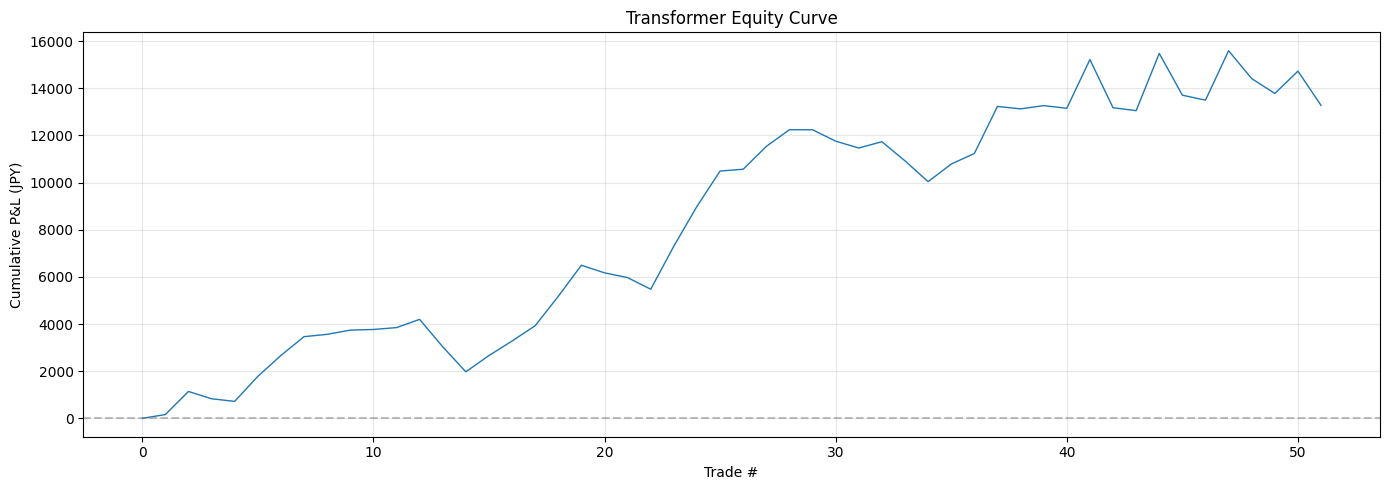

In [8]:
probs_test = predict_transformer(model, X_test_raw, y_test_final.loc[X_test_raw.index], BEST_WINDOW_SIZE)
test_indices = X_test_raw.index[BEST_WINDOW_SIZE:]
preds_test = predict_with_thresholds(probs_test, THRESHOLD_BUY, THRESHOLD_SELL)

backtest_config = {**CONFIG, "atr_threshold": ATR_THRESHOLD}
result = run_backtest(preds_test, test_indices, df, df_features, backtest_config)
metrics = compute_metrics(result, CONFIG)

print("=== Transformer Backtest Results ===")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

plot_equity_curve(result, title="Transformer Equity Curve")

In [9]:
import json

metrics_out = {}
for k, v in metrics.items():
    metrics_out[k] = float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v

with open(ARTIFACT_DIR / "metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

print(f"Metrics saved to {ARTIFACT_DIR / 'metrics.json'}")
print(f"Sharpe Ratio: {metrics_out.get('sharpe_ratio', 'N/A')}")

Metrics saved to ..\artifacts\transformer\metrics.json
Sharpe Ratio: 3.303503341128951


In [10]:
torch.save(model.state_dict(), ARTIFACT_DIR / "model.pt")

config_save = CONFIG.copy()
config_save["THRESHOLD_PIPS"] = BEST_THRESHOLD_PIPS
config_save["THRESHOLD_BUY"] = THRESHOLD_BUY
config_save["THRESHOLD_SELL"] = THRESHOLD_SELL
config_save["ATR_THRESHOLD"] = ATR_THRESHOLD
config_save["WINDOW_SIZE"] = BEST_WINDOW_SIZE
config_save["model_params"] = {
    "n_features": len(feature_cols),
    "d_model": bp["d_model"],
    "nhead": bp["nhead"],
    "num_layers": bp["num_layers"],
    "dim_feedforward": bp["dim_feedforward"],
    "dropout": bp["dropout"],
}
config_save["feature_cols"] = feature_cols

with open(ARTIFACT_DIR / "config.pkl", "wb") as f:
    pickle.dump(config_save, f)

print(f"Artifacts saved to {ARTIFACT_DIR}")

Artifacts saved to ..\artifacts\transformer
